In [1]:
import pandas as pd
from pathlib import Path

raw_dir = Path("../data/raw")

nav_files = list(raw_dir.glob("*nav_history*.csv"))

print("NAV files found:", nav_files)

nav_df = pd.read_csv(nav_files[0])

print("Shape:", nav_df.shape)
print("Columns:", nav_df.columns.tolist())
print(nav_df.head())

NAV files found: [WindowsPath('../data/raw/1788499983331-4389156d-02_nav_history.csv')]
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [7]:
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")

nav_df = nav_df[
    (nav_df["date"] >= "2022-01-01") &
    (nav_df["date"] <= "2026-12-31")
].copy()

nav_df = nav_df.sort_values(["amfi_code", "date"])

print("Date range:", nav_df["date"].min(), "to", nav_df["date"].max())
print("Number of schemes:", nav_df["amfi_code"].nunique())
print("Rows:", len(nav_df))

Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Number of schemes: 40
Rows: 46000


In [12]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend – 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.update_layout(
    hovermode="x unified",
    height=700
)

fig.show()

In [16]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend – 40 Schemes (2022–2026)"
)

# 2023 period
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 period
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    hovermode="x unified",
    height=700
)

fig.show()

In [21]:
%pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
from pathlib import Path

raw_dir = Path("../data/raw")

csv_files = list(raw_dir.glob("*.csv"))

for file in csv_files:
    print("\nFILE:", file.name)
    temp_df = pd.read_csv(file, nrows=5)
    print("COLUMNS:", temp_df.columns.tolist())


FILE: 1788499980509-304c1255-08_investor_transactions.csv
COLUMNS: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

FILE: 1788499982117-e3d6ab98-09_portfolio_holdings.csv
COLUMNS: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

FILE: 1788499982615-f9647ab2-10_benchmark_indices.csv
COLUMNS: ['date', 'index_name', 'close_value']

FILE: 1788499983024-b042c300-01_fund_master.csv
COLUMNS: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

FILE: 1788499983331-4389156d-02_nav_history.csv
COLUMNS: ['amfi_code', 'date', 'nav']

FILE: 1788499984134-b0cbf625-03_aum_by_fund_house.csv
COLUMNS: ['

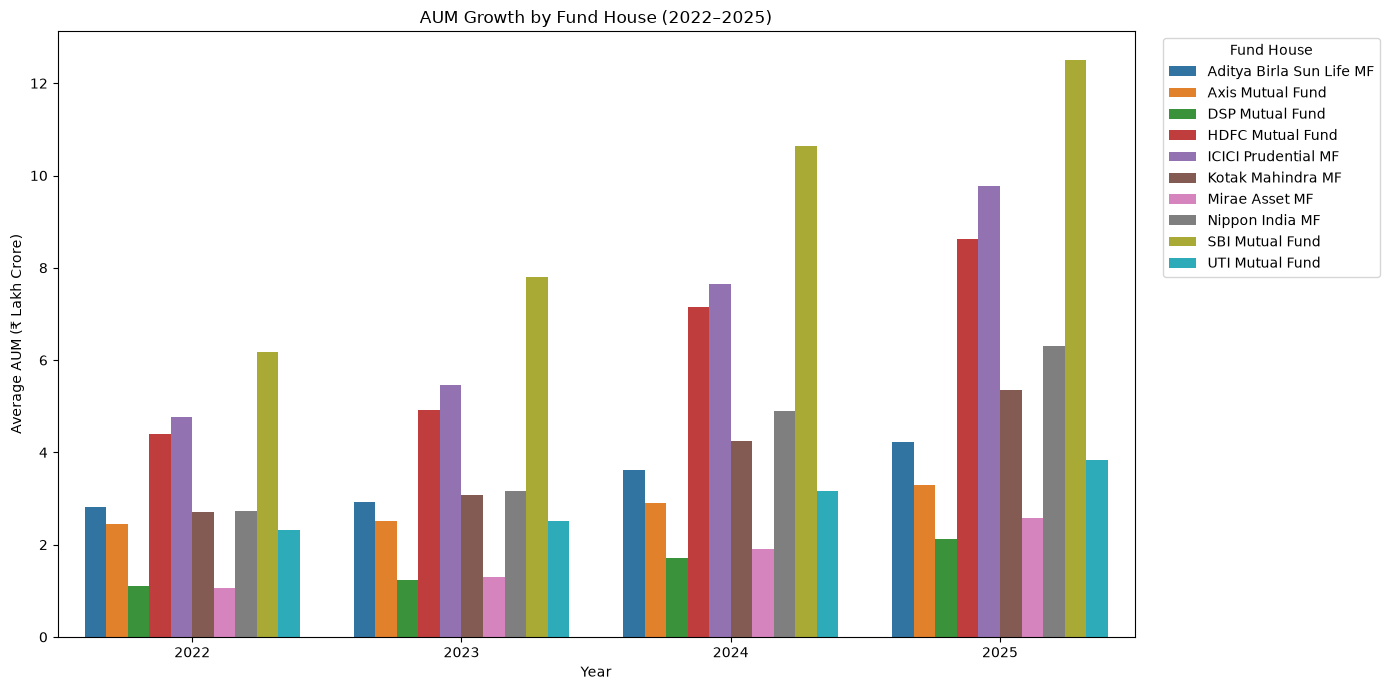

In [27]:
# Chart 3: AUM Growth by Fund House (2022–2025)

aum_file = list(raw_dir.glob("*aum_by_fund_house*.csv"))[0]

aum_df = pd.read_csv(aum_file)

aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")

aum_df = aum_df[
    (aum_df["date"] >= "2022-01-01") &
    (aum_df["date"] <= "2025-12-31")
].copy()

# Get year
aum_df["year"] = aum_df["date"].dt.year

# Yearly AUM by fund house
yearly_aum = (
    aum_df
    .groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .mean()
)

# Plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [30]:
# Chart 4: Monthly SIP Inflow Trend

sip_file = list(raw_dir.glob("*monthly_sip_inflows*.csv"))[0]

sip_df = pd.read_csv(sip_file)

sip_df["month"] = pd.to_datetime(sip_df["month"], errors="coerce")

sip_df = sip_df[
    (sip_df["month"] >= "2022-01-01") &
    (sip_df["month"] <= "2025-12-31")
].copy()

# Plot
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Highlight December 2025
dec_2025 = sip_df[sip_df["month"] == "2025-12-01"]

if not dec_2025.empty:
    high_value = dec_2025["sip_inflow_crore"].iloc[0]

    fig.add_scatter(
        x=dec_2025["month"],
        y=dec_2025["sip_inflow_crore"],
        mode="markers+text",
        text=[f"₹{high_value:,.0f} Cr"],
        textposition="top center",
        name="Dec 2025 High"
    )

fig.update_layout(
    hovermode="x unified",
    height=600
)

fig.show()

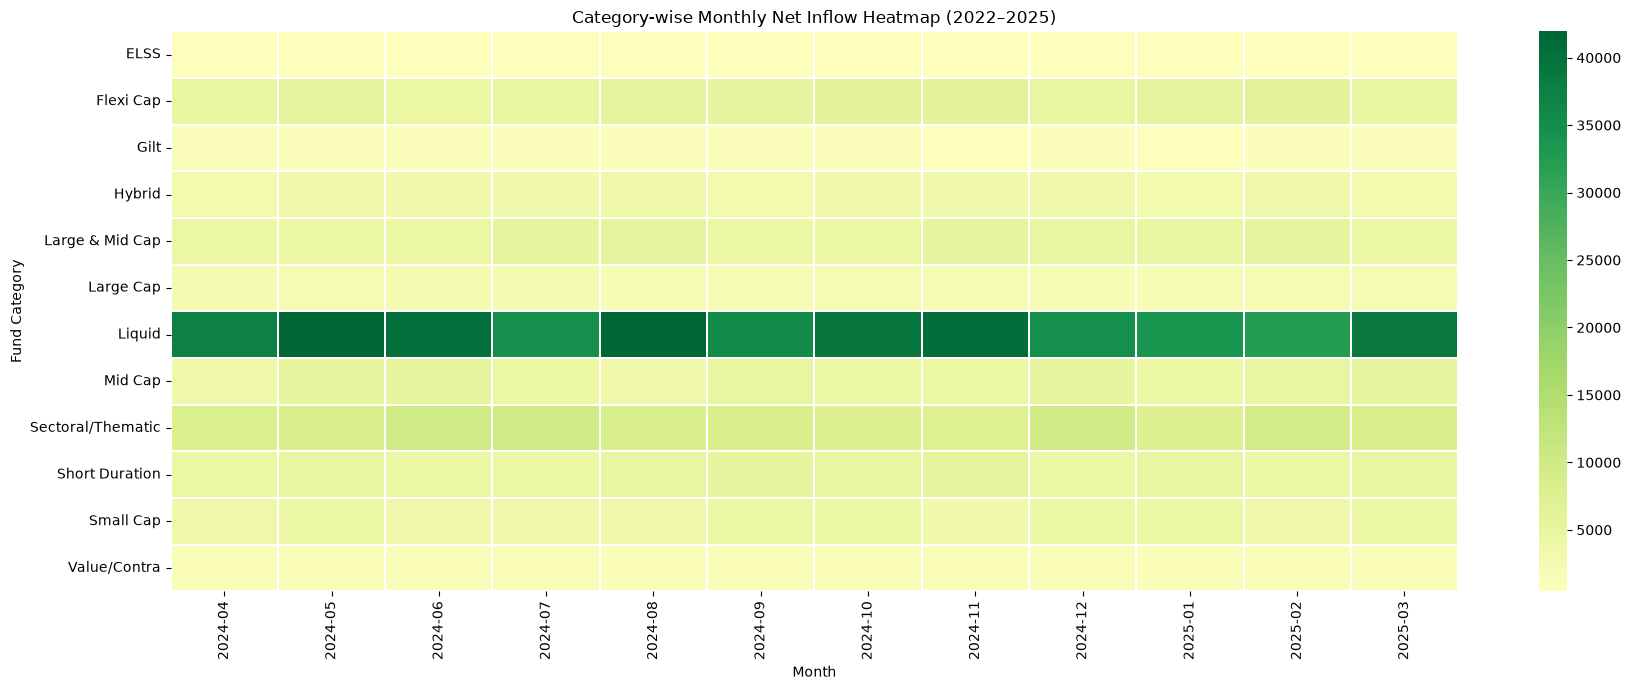

In [33]:
# Chart 5: Category Inflow Heatmap

category_file = list(raw_dir.glob("*category_inflows*.csv"))[0]

category_df = pd.read_csv(category_file)

category_df["month"] = pd.to_datetime(
    category_df["month"],
    errors="coerce"
)

category_df = category_df[
    (category_df["month"] >= "2022-01-01") &
    (category_df["month"] <= "2025-12-31")
].copy()

# Create month labels
category_df["month_label"] = category_df["month"].dt.strftime("%Y-%m")

# Pivot table
heatmap_data = category_df.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Plot heatmap
plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    linewidths=0.3
)

plt.title("Category-wise Monthly Net Inflow Heatmap (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

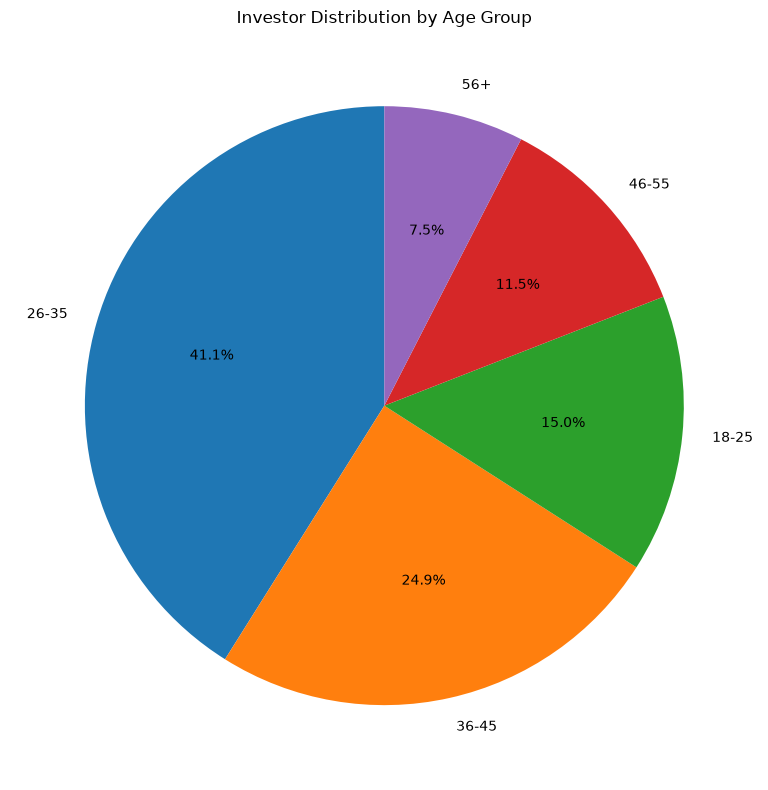

In [36]:
# Chart 6: Investor Age Group Distribution

investor_file = list(raw_dir.glob("*investor_transactions*.csv"))[0]

investor_df = pd.read_csv(investor_file)

age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.tight_layout()
plt.show()

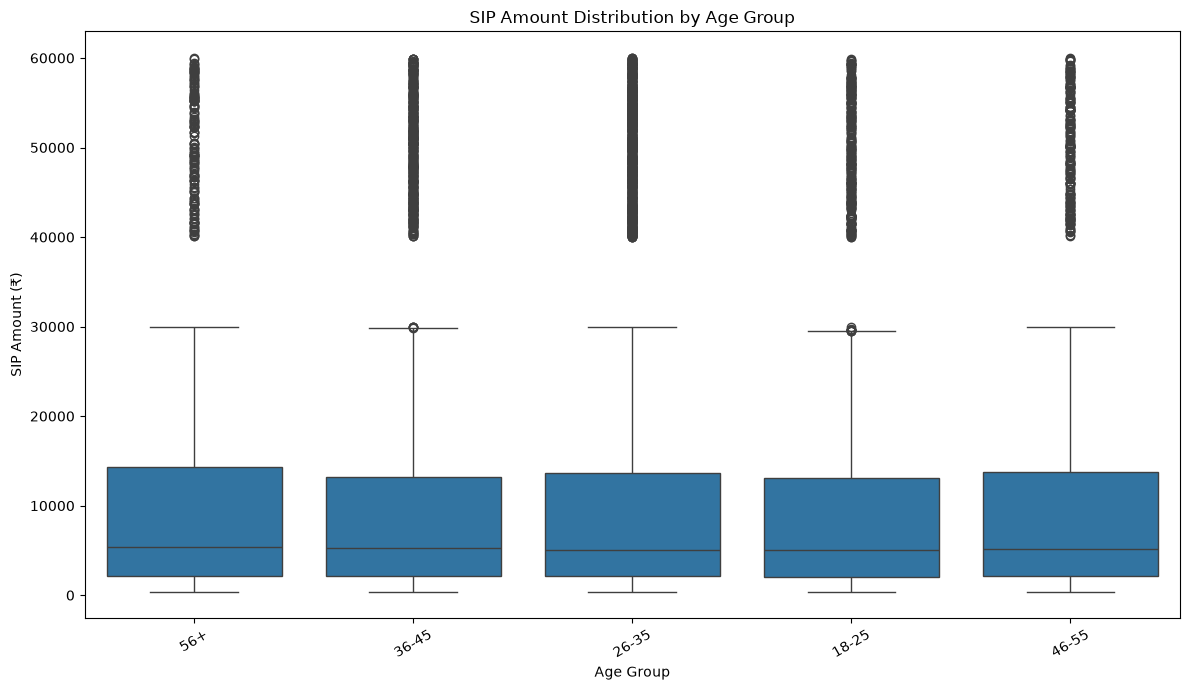

In [39]:
# Chart 7: SIP Amount Distribution by Age Group

sip_transactions = investor_df[
    investor_df["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

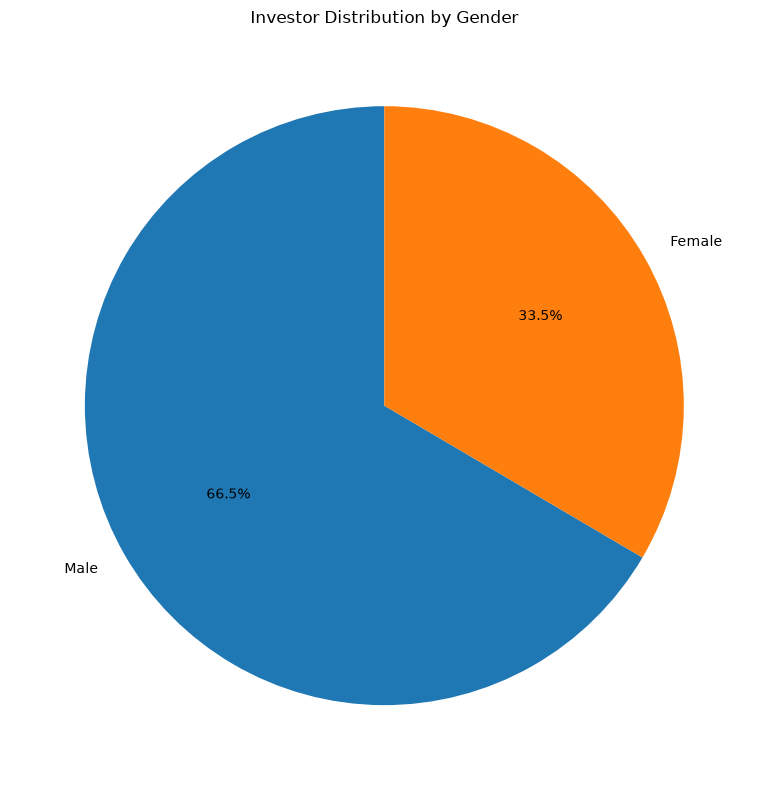

In [42]:
# Chart 8: Investor Gender Split

gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Gender")

plt.tight_layout()
plt.show()

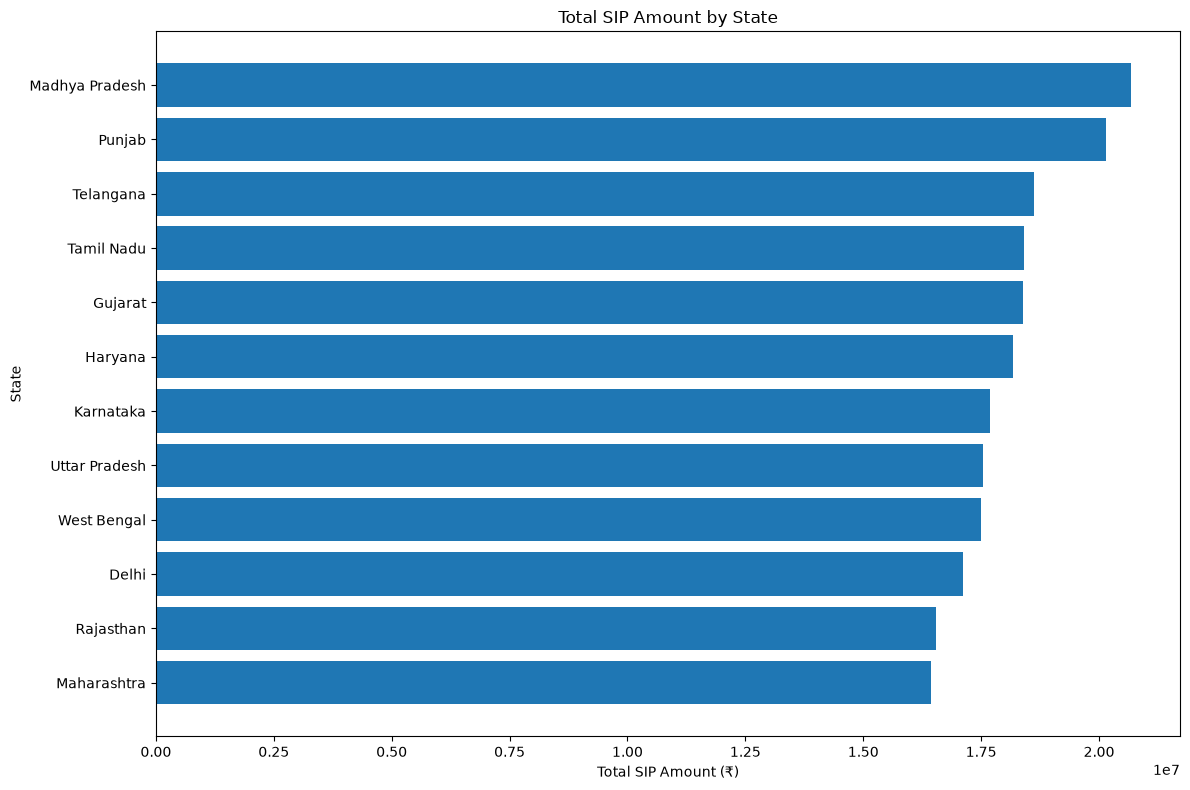

In [45]:
# Chart 9: SIP Amount by State

state_sip = (
    investor_df[
        investor_df["transaction_type"].astype(str).str.upper() == "SIP"
    ]
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip["state"],
    state_sip["amount_inr"]
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

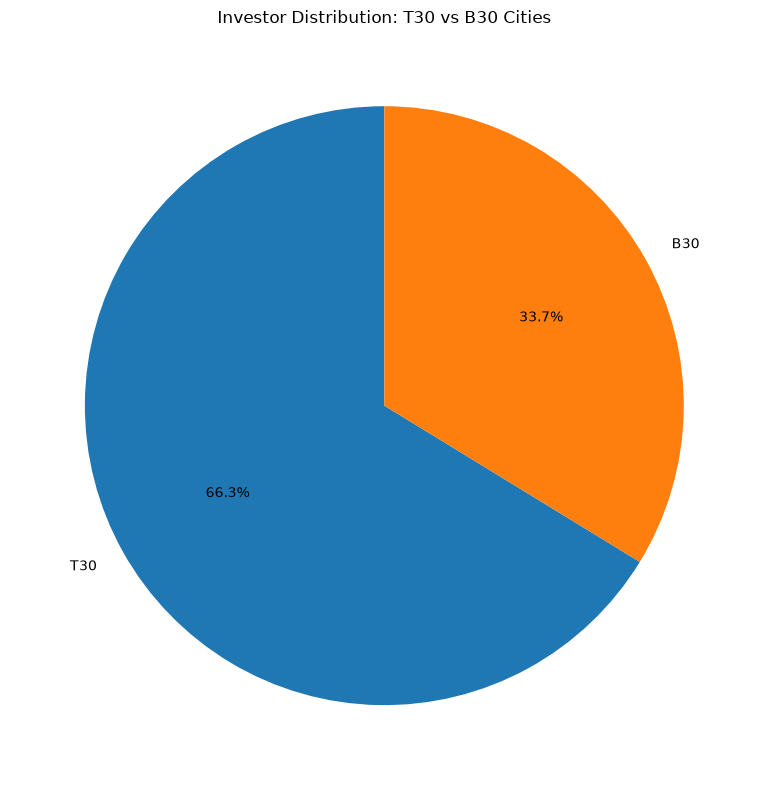

In [48]:
# Chart 10: T30 vs B30 City Tier Distribution

city_tier_counts = investor_df["city_tier"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    city_tier_counts.values,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.tight_layout()
plt.show()

In [54]:
# Chart 11: Folio Count Growth

folio_file = list(raw_dir.glob("*industry_folio_count*.csv"))[0]

folio_df = pd.read_csv(folio_file)

folio_df["month"] = pd.to_datetime(
    folio_df["month"],
    errors="coerce"
)

folio_df = folio_df[
    (folio_df["month"] >= "2022-01-01") &
    (folio_df["month"] <= "2025-12-31")
].copy()

folio_df = folio_df.sort_values("month")

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Total Mutual Fund Folio Count Growth (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    },
    markers=True
)

# Mark starting point
start = folio_df.iloc[0]

fig.add_scatter(
    x=[start["month"]],
    y=[start["total_folios_crore"]],
    mode="markers+text",
    text=[f"{start['total_folios_crore']:.2f} Cr"],
    textposition="bottom right",
    name="Jan 2022"
)

# Mark ending point
end = folio_df.iloc[-1]

fig.add_scatter(
    x=[end["month"]],
    y=[end["total_folios_crore"]],
    mode="markers+text",
    text=[f"{end['total_folios_crore']:.2f} Cr"],
    textposition="top left",
    name="Dec 2025"
)

fig.update_layout(
    hovermode="x unified",
    height=600
)

fig.show()

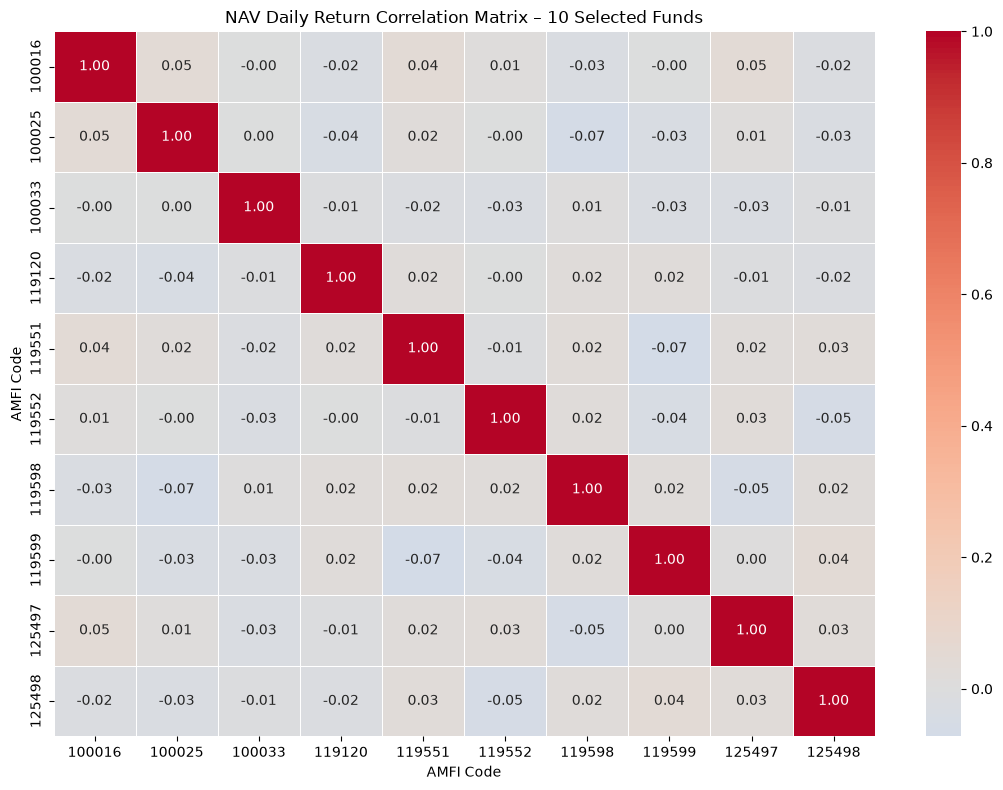

In [58]:
# Chart 12: NAV Return Correlation Matrix – 10 Selected Funds

# Select 10 funds
selected_codes = (
    nav_df["amfi_code"]
    .drop_duplicates()
    .head(10)
    .tolist()
)

selected_nav = nav_df[
    nav_df["amfi_code"].isin(selected_codes)
].copy()

# Convert NAV data into columns for each fund
nav_pivot = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
daily_returns = nav_pivot.pct_change()

# Correlation matrix
correlation_matrix = daily_returns.corr()

# Plot heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("NAV Daily Return Correlation Matrix – 10 Selected Funds")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.show()

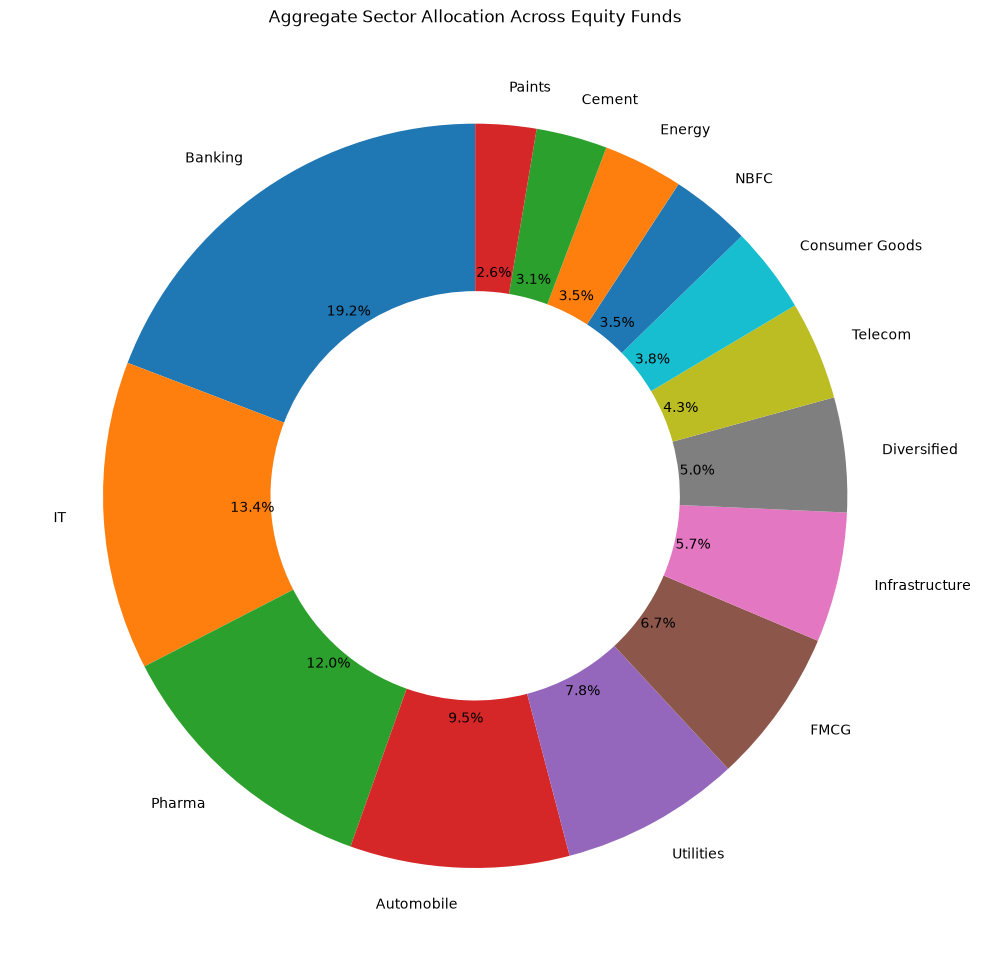

In [62]:
# Chart 13: Aggregate Sector Allocation

portfolio_file = list(raw_dir.glob("*portfolio_holdings*.csv"))[0]

portfolio_df = pd.read_csv(portfolio_file)

# Aggregate sector weights across all holdings
sector_allocation = (
    portfolio_df
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

# Keep sectors with valid positive weights
sector_allocation = sector_allocation[
    sector_allocation["weight_pct"] > 0
].copy()

# Donut chart
plt.figure(figsize=(10, 10))

plt.pie(
    sector_allocation["weight_pct"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Aggregate Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()

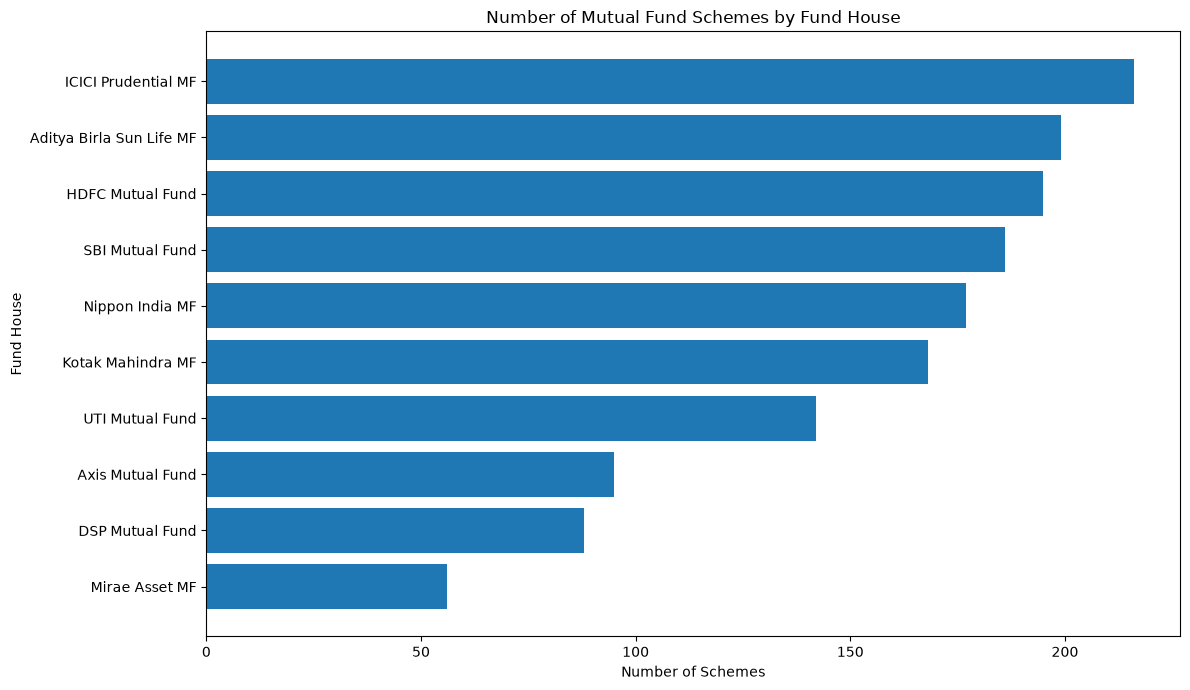

In [66]:
# Chart 14: Number of Schemes by Fund House

scheme_count = (
    aum_df
    .groupby("fund_house")["num_schemes"]
    .max()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    scheme_count.index,
    scheme_count.values
)

plt.title("Number of Mutual Fund Schemes by Fund House")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

plt.tight_layout()
plt.show()

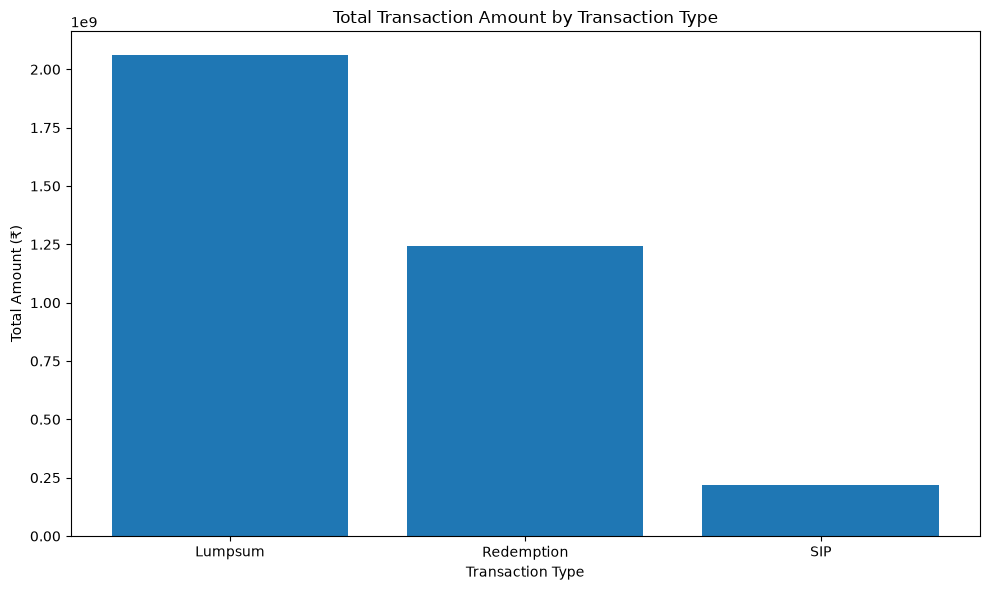

In [70]:
# Chart 15: Transaction Type Analysis

transaction_summary = (
    investor_df
    .groupby("transaction_type", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    transaction_summary["transaction_type"],
    transaction_summary["amount_inr"]
)

plt.title("Total Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount (₹)")

plt.tight_layout()
plt.show()

In [71]:
# Check remaining CSV files and their columns

for file in raw_dir.glob("*.csv"):
    if "folio" in file.name.lower():
        print("FILE:", file.name)
        temp = pd.read_csv(file, nrows=5)
        print("COLUMNS:", temp.columns.tolist())

FILE: 1788499982117-e3d6ab98-09_portfolio_holdings.csv
COLUMNS: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
FILE: 1788499985036-da4a0c4a-06_industry_folio_count.csv
COLUMNS: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [74]:
# Exact EDA statistics for final findings

print("===== AUM =====")
print(
    aum_df.groupby("fund_house")["aum_lakh_crore"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print("\n===== SIP INFLOW =====")
max_sip = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]
print("Highest SIP inflow:")
print(max_sip[["month", "sip_inflow_crore"]])

print("\n===== FOLIO COUNT =====")
print("Starting folios:")
print(folio_df.iloc[0][["month", "total_folios_crore"]])
print("Ending folios:")
print(folio_df.iloc[-1][["month", "total_folios_crore"]])

print("\n===== AGE GROUP =====")
print(
    investor_df["age_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== GENDER =====")
print(
    investor_df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== STATE SIP =====")
state_result = (
    investor_df[
        investor_df["transaction_type"].astype(str).str.upper() == "SIP"
    ]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)
print(state_result.head(10))

print("\n===== CITY TIER =====")
print(
    investor_df["city_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== TRANSACTION TYPE =====")
print(
    investor_df.groupby("transaction_type")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== SECTOR =====")
print(
    portfolio_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

===== AUM =====
fund_house
SBI Mutual Fund        9.434444
ICICI Prudential MF    6.992222
HDFC Mutual Fund       6.368889
Nippon India MF        4.343333
Kotak Mahindra MF      3.891111
Name: aum_lakh_crore, dtype: float64

===== SIP INFLOW =====
Highest SIP inflow:
month               2025-12-01 00:00:00
sip_inflow_crore                  31002
Name: 47, dtype: object

===== FOLIO COUNT =====
Starting folios:
month                 2022-01-01 00:00:00
total_folios_crore                  13.26
Name: 0, dtype: object
Ending folios:
month                 2025-12-01 00:00:00
total_folios_crore                  26.12
Name: 20, dtype: object

===== AGE GROUP =====
age_group
26-35    41.07
36-45    24.85
18-25    15.00
46-55    11.53
56+       7.55
Name: proportion, dtype: float64

===== GENDER =====
gender
Male      66.54
Female    33.46
Name: proportion, dtype: float64

===== STATE SIP =====
state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
raw_dir = Path("../data/raw")

nav_files = list(raw_dir.glob("*nav_history*.csv"))

print("NAV files found:", nav_files)

nav_df = pd.read_csv(nav_files[0])

print("Shape:", nav_df.shape)
print("Columns:", nav_df.columns.tolist())
print(nav_df.head())

NAV files found: [WindowsPath('../data/raw/1788499983331-4389156d-02_nav_history.csv')]
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


## 10 Key EDA Findings

1. **SBI Mutual Fund has the highest average AUM:**  
   SBI Mutual Fund recorded the highest average AUM at **₹9.43 lakh crore**, followed by ICICI Prudential MF at **₹6.99 lakh crore** and HDFC Mutual Fund at **₹6.37 lakh crore**.  
   **Chart Reference:** Chart 3 – AUM Growth by Fund House.

2. **SIP inflows reached an all-time high in December 2025:**  
   Monthly SIP inflows reached **₹31,002 crore in December 2025**, representing the highest SIP inflow observed in the analyzed 2022–2025 dataset.  
   **Chart Reference:** Chart 4 – Monthly SIP Inflow Trend.

3. **Mutual fund folios nearly doubled:**  
   Total mutual fund folios increased from **13.26 crore in January 2022 to 26.12 crore in December 2025**, representing an increase of approximately **97%**.  
   **Chart Reference:** Chart 11 – Folio Count Growth.

4. **Young and middle-aged investors dominate the dataset:**  
   Investors aged **26–35 account for 41.07%** of the dataset, followed by the **36–45 age group at 24.85%**. Together, these two groups represent **65.92%** of investors.  
   **Chart Reference:** Chart 6 – Investor Age Group Distribution.

5. **Male investors form the majority:**  
   The dataset contains **66.54% male investors** and **33.46% female investors**, showing a higher representation of male investors in the analyzed transactions.  
   **Chart Reference:** Chart 8 – Investor Gender Split.

6. **T30 cities contribute a larger share of investors:**  
   Investors from **T30 cities account for 66.26%**, while B30 cities account for **33.74%** of the dataset.  
   **Chart Reference:** Chart 10 – T30 vs B30 City Tier Distribution.

7. **Madhya Pradesh has the highest SIP transaction amount:**  
   Among the states analyzed, **Madhya Pradesh recorded the highest total SIP amount at ₹2.07 crore**, followed by Punjab at approximately **₹2.01 crore**.  
   **Chart Reference:** Chart 9 – SIP Amount by State.

8. **Lumpsum transactions have the highest transaction value:**  
   Lumpsum transactions contributed approximately **₹205.98 crore**, compared with **₹124.45 crore from Redemptions** and **₹21.72 crore from SIP transactions** in the analyzed transaction dataset.  
   **Chart Reference:** Chart 15 – Total Transaction Amount by Transaction Type.

9. **Banking has the highest aggregate sector weight:**  
   Banking recorded the highest aggregate sector weight at **652.26**, followed by IT at **455.47** and Pharma at **407.45** across the portfolio holdings dataset.  
   **Chart Reference:** Chart 13 – Aggregate Sector Allocation.

10. **Fund returns show varying relationships:**  
    The NAV return correlation analysis indicates that the selected mutual fund schemes have different levels of relationship in their daily returns, providing useful information about diversification and common market movement.  
    **Chart Reference:** Chart 12 – NAV Daily Return Correlation Matrix.

In [3]:
from pathlib import Path

png_dir = Path("../reports/eda_charts")
png_dir.mkdir(parents=True, exist_ok=True)

print("PNG folder created:")
print(png_dir.resolve())

PNG folder created:
C:\Users\saras\OneDrive\Desktop\Bluestock_MF_Project\reports\eda_charts


In [4]:
# Export Chart 1 as PNG

fig1 = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend – 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig1.update_layout(
    hovermode="x unified",
    height=700
)

fig1.write_image("../reports/eda_charts/chart_01_daily_nav_trend.png")

fig1.show()

print("Chart 1 PNG saved successfully!")

Chart 1 PNG saved successfully!


In [5]:
%pip install --upgrade "kaleido>=1"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
fig1 = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend – 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig1.update_layout(
    hovermode="x unified",
    height=700
)

fig1.write_image(
    "../reports/eda_charts/chart_01_daily_nav_trend.png",
    width=1400,
    height=700
)

print("Chart 1 PNG saved successfully!")

Chart 1 PNG saved successfully!


In [7]:
fig2 = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend – 40 Schemes (2022–2026)"
)

fig2.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig2.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig2.update_layout(
    hovermode="x unified",
    height=700
)

fig2.write_image(
    "../reports/eda_charts/chart_02_nav_highlights.png",
    width=1400,
    height=700
)

print("Chart 2 PNG saved successfully!")

Chart 2 PNG saved successfully!


In [8]:
fig3 = plt.figure(figsize=(14, 7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Lakh Crore)")
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_03_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 3 PNG saved successfully!")

NameError: name 'yearly_aum' is not defined

<Figure size 1400x700 with 0 Axes>

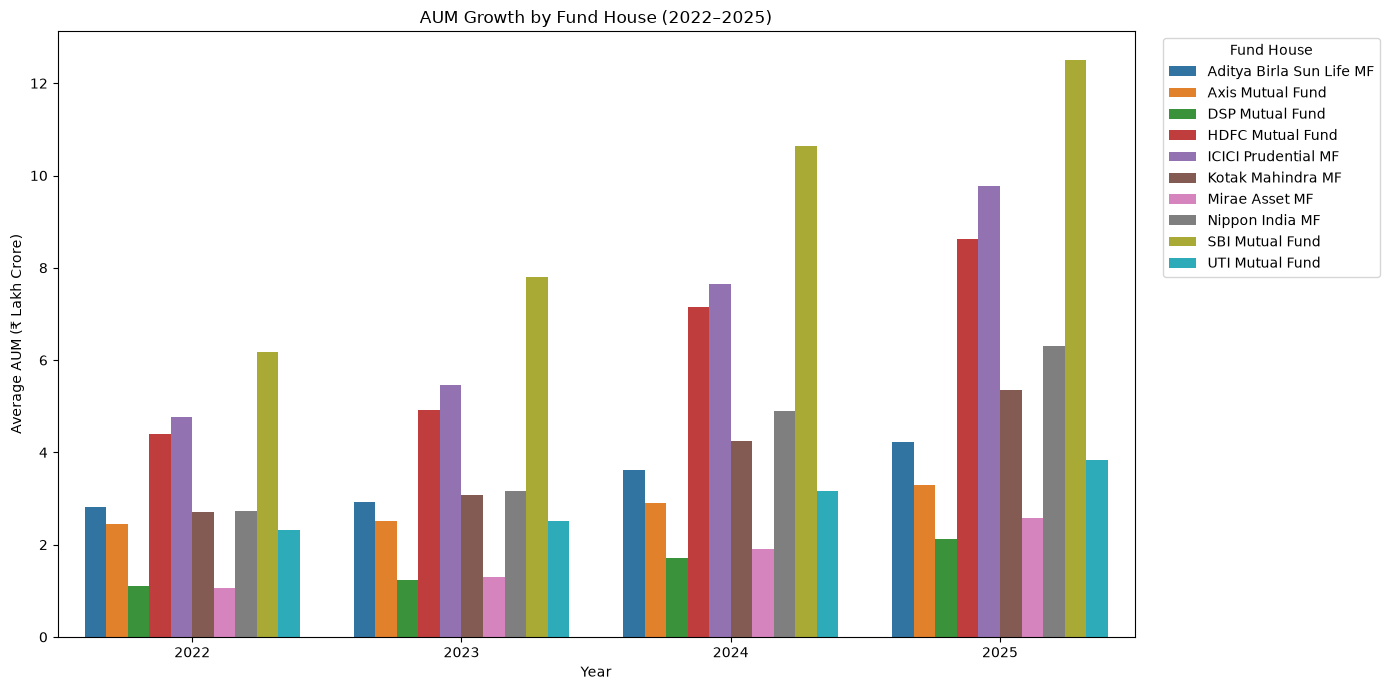

Chart 3 PNG saved successfully!


In [9]:
# Chart 3: AUM Growth by Fund House - PNG Export

aum_file = list(raw_dir.glob("*aum_by_fund_house*.csv"))[0]
aum_df = pd.read_csv(aum_file)

aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")

aum_df = aum_df[
    (aum_df["date"] >= "2022-01-01") &
    (aum_df["date"] <= "2025-12-31")
].copy()

aum_df["year"] = aum_df["date"].dt.year

yearly_aum = (
    aum_df
    .groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .mean()
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Lakh Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_03_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 3 PNG saved successfully!")

In [10]:
# Chart 4: Monthly SIP Inflow - PNG Export

sip_file = list(raw_dir.glob("*monthly_sip_inflows*.csv"))[0]
sip_df = pd.read_csv(sip_file)

sip_df["month"] = pd.to_datetime(sip_df["month"], errors="coerce")

sip_df = sip_df[
    (sip_df["month"] >= "2022-01-01") &
    (sip_df["month"] <= "2025-12-31")
].copy()

fig4 = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

dec_2025 = sip_df[sip_df["month"] == "2025-12-01"]

if not dec_2025.empty:
    high_value = dec_2025["sip_inflow_crore"].iloc[0]

    fig4.add_scatter(
        x=dec_2025["month"],
        y=dec_2025["sip_inflow_crore"],
        mode="markers+text",
        text=[f"₹{high_value:,.0f} Cr"],
        textposition="top center",
        name="Dec 2025 High"
    )

fig4.update_layout(
    hovermode="x unified",
    height=600
)

fig4.write_image(
    "../reports/eda_charts/chart_04_sip_inflow.png",
    width=1400,
    height=700
)

print("Chart 4 PNG saved successfully!")

Chart 4 PNG saved successfully!


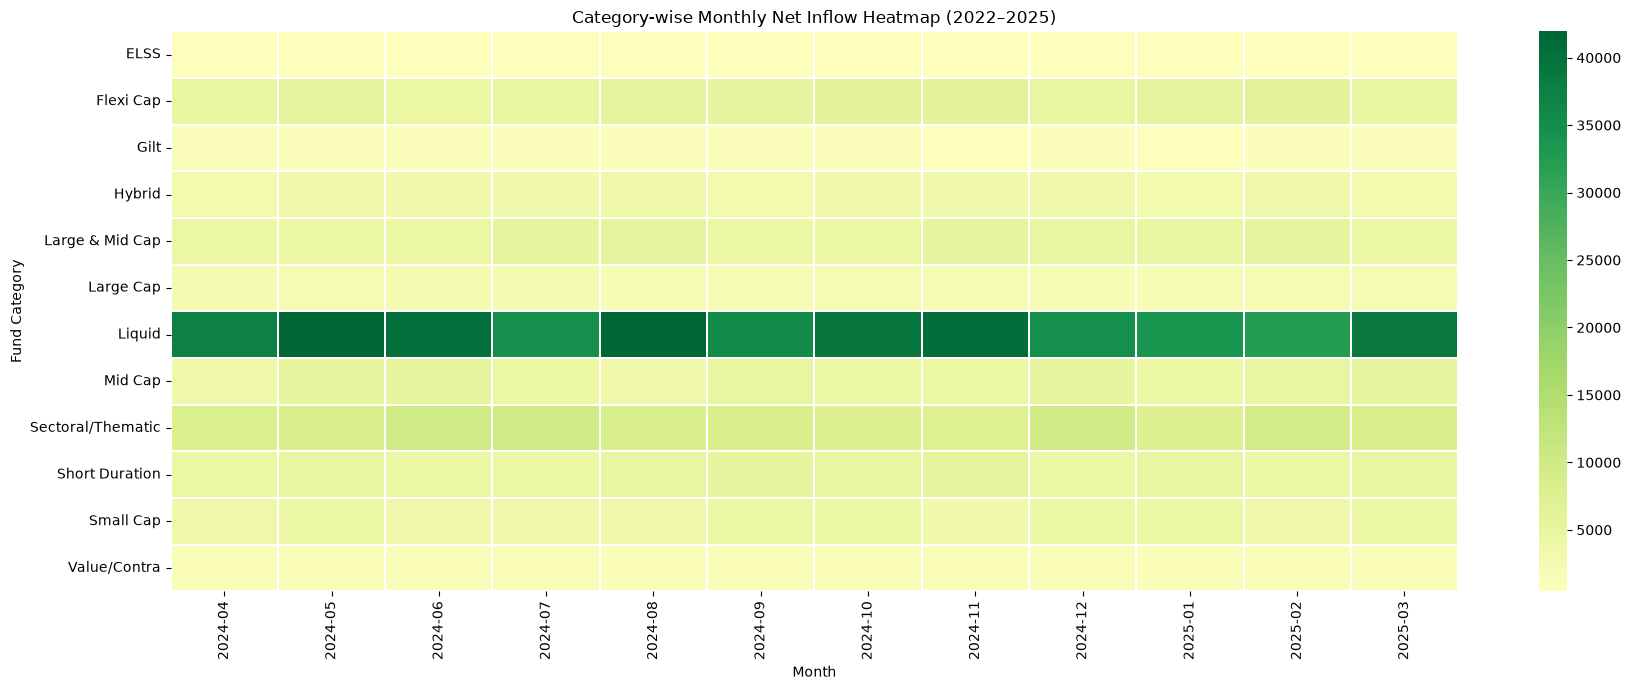

Chart 5 PNG saved successfully!


In [11]:
# Chart 5: Category Inflow Heatmap - PNG Export

category_file = list(raw_dir.glob("*category_inflows*.csv"))[0]
category_df = pd.read_csv(category_file)

category_df["month"] = pd.to_datetime(
    category_df["month"],
    errors="coerce"
)

category_df = category_df[
    (category_df["month"] >= "2022-01-01") &
    (category_df["month"] <= "2025-12-31")
].copy()

category_df["month_label"] = category_df["month"].dt.strftime("%Y-%m")

heatmap_data = category_df.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    linewidths=0.3
)

plt.title("Category-wise Monthly Net Inflow Heatmap (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_05_category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 5 PNG saved successfully!")

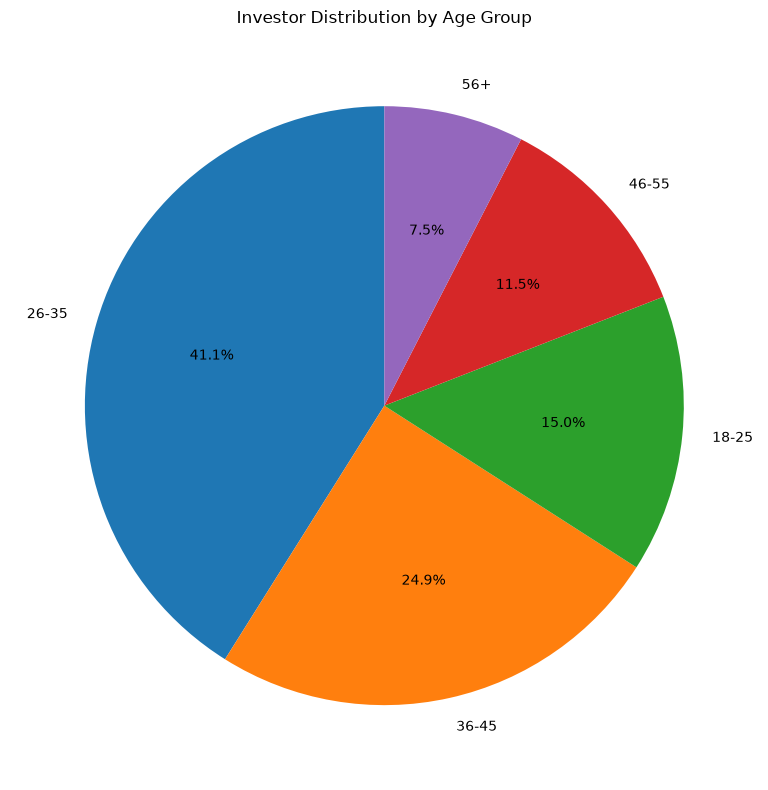

Chart 6 PNG saved successfully!


In [12]:
# Chart 6: Investor Age Group Distribution - PNG Export

investor_file = list(raw_dir.glob("*investor_transactions*.csv"))[0]
investor_df = pd.read_csv(investor_file)

age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_06_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 6 PNG saved successfully!")

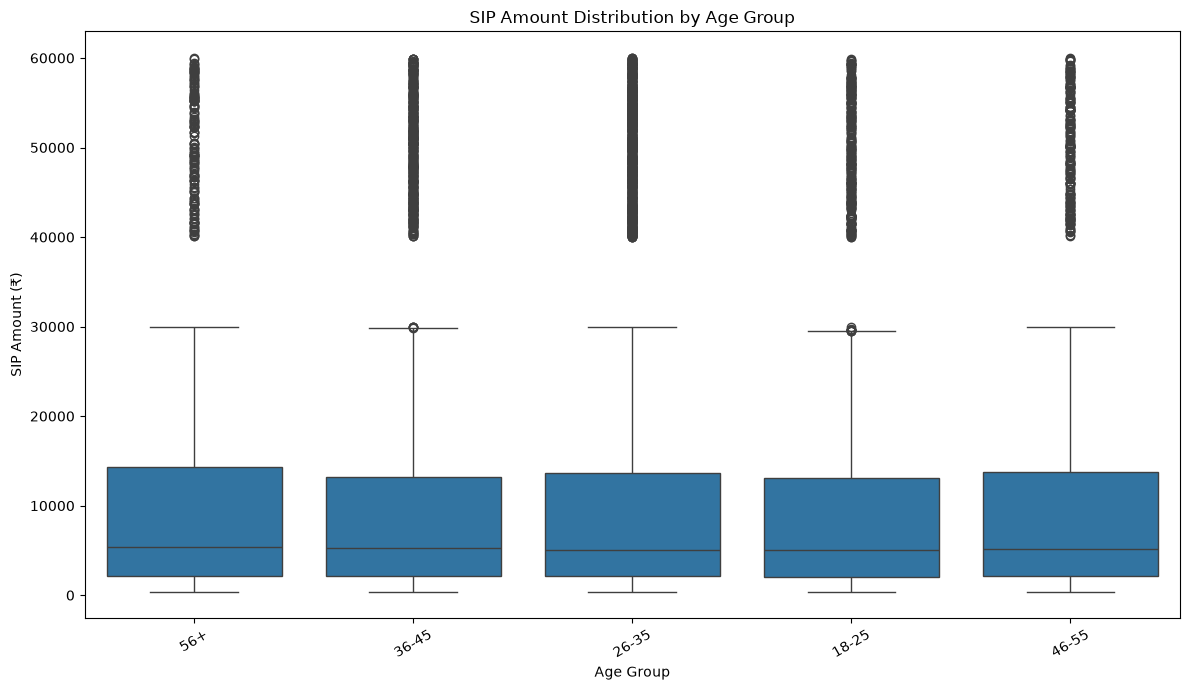

Chart 7 PNG saved successfully!


In [13]:
# Chart 7: SIP Amount Distribution by Age Group - PNG Export

sip_transactions = investor_df[
    investor_df["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_07_sip_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 7 PNG saved successfully!")

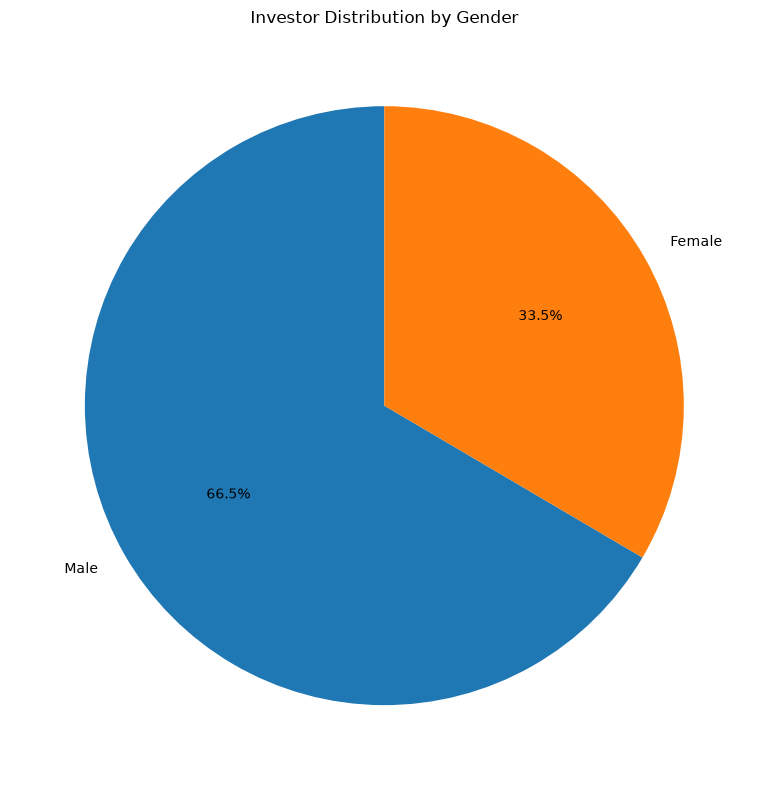

Chart 8 PNG saved successfully!


In [14]:
# Chart 8: Investor Gender Split - PNG Export

gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Gender")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_08_gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 8 PNG saved successfully!")

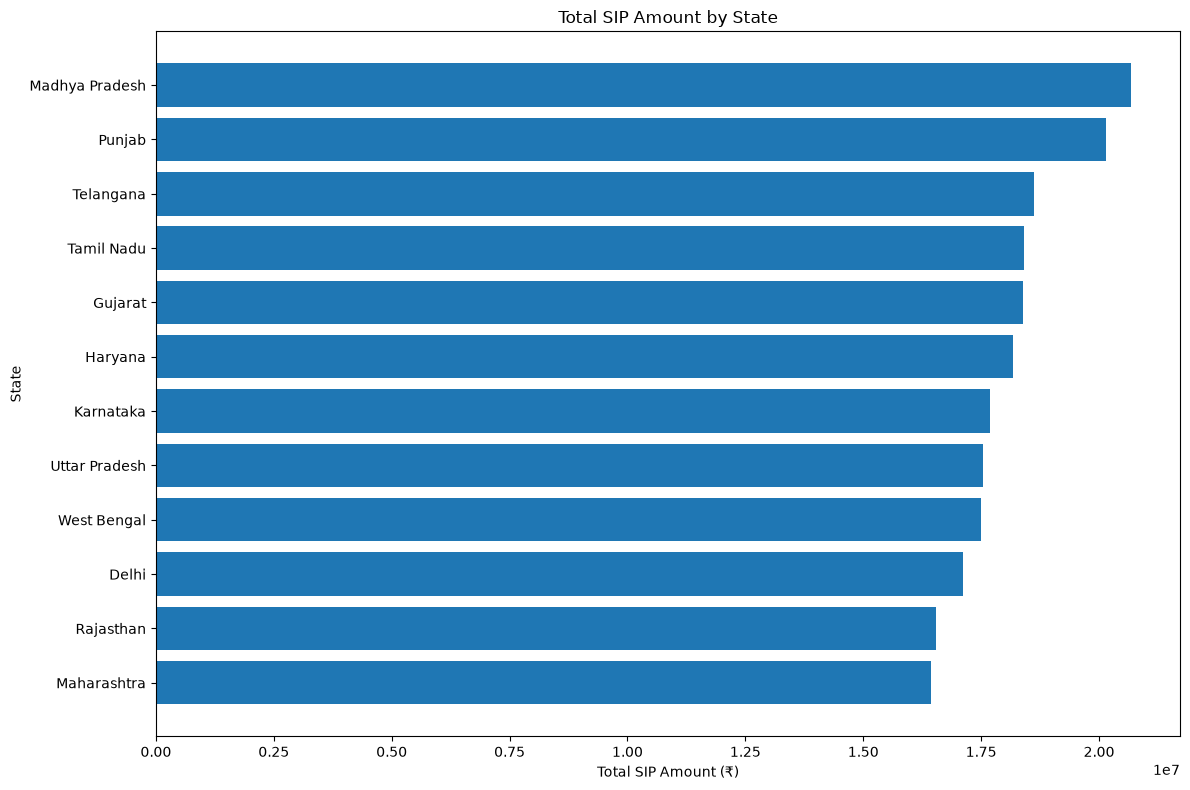

Chart 9 PNG saved successfully!


In [15]:
# Chart 9: SIP Amount by State - PNG Export

state_sip = (
    investor_df[
        investor_df["transaction_type"].astype(str).str.upper() == "SIP"
    ]
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip["state"],
    state_sip["amount_inr"]
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_09_sip_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 9 PNG saved successfully!")

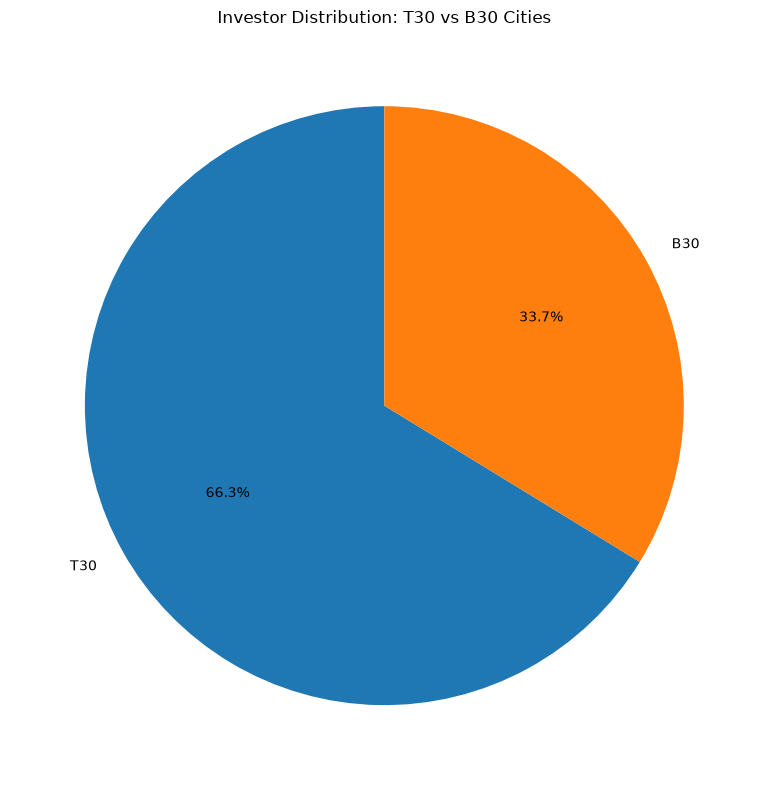

Chart 10 PNG saved successfully!


In [16]:
# Chart 10: T30 vs B30 City Tier - PNG Export

city_tier_counts = investor_df["city_tier"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    city_tier_counts.values,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_10_t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 10 PNG saved successfully!")

In [17]:
# Chart 11: Folio Count Growth - PNG Export

folio_file = list(raw_dir.glob("*industry_folio_count*.csv"))[0]

folio_df = pd.read_csv(folio_file)

folio_df["month"] = pd.to_datetime(
    folio_df["month"],
    errors="coerce"
)

folio_df = folio_df[
    (folio_df["month"] >= "2022-01-01") &
    (folio_df["month"] <= "2025-12-31")
].copy()

folio_df = folio_df.sort_values("month")

fig11 = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Total Mutual Fund Folio Count Growth (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    },
    markers=True
)

# Starting point
start = folio_df.iloc[0]

fig11.add_scatter(
    x=[start["month"]],
    y=[start["total_folios_crore"]],
    mode="markers+text",
    text=[f"{start['total_folios_crore']:.2f} Cr"],
    textposition="bottom right",
    name="Jan 2022"
)

# Ending point
end = folio_df.iloc[-1]

fig11.add_scatter(
    x=[end["month"]],
    y=[end["total_folios_crore"]],
    mode="markers+text",
    text=[f"{end['total_folios_crore']:.2f} Cr"],
    textposition="top left",
    name="Dec 2025"
)

fig11.update_layout(
    hovermode="x unified",
    height=600
)

fig11.write_image(
    "../reports/eda_charts/chart_11_folio_growth.png",
    width=1400,
    height=700
)

print("Chart 11 PNG saved successfully!")

Chart 11 PNG saved successfully!


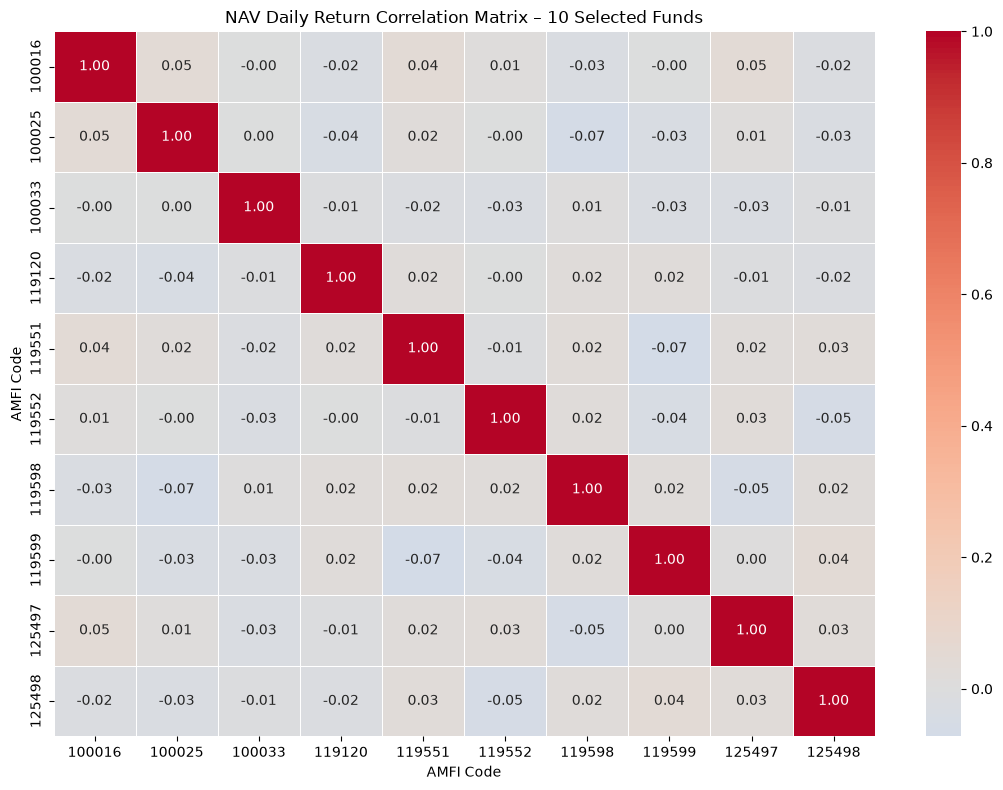

Chart 12 PNG saved successfully!


In [18]:
# Chart 12: NAV Return Correlation Matrix - PNG Export

selected_codes = (
    nav_df["amfi_code"]
    .drop_duplicates()
    .head(10)
    .tolist()
)

selected_nav = nav_df[
    nav_df["amfi_code"].isin(selected_codes)
].copy()

nav_pivot = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change()

correlation_matrix = daily_returns.corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("NAV Daily Return Correlation Matrix – 10 Selected Funds")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_12_nav_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 12 PNG saved successfully!")

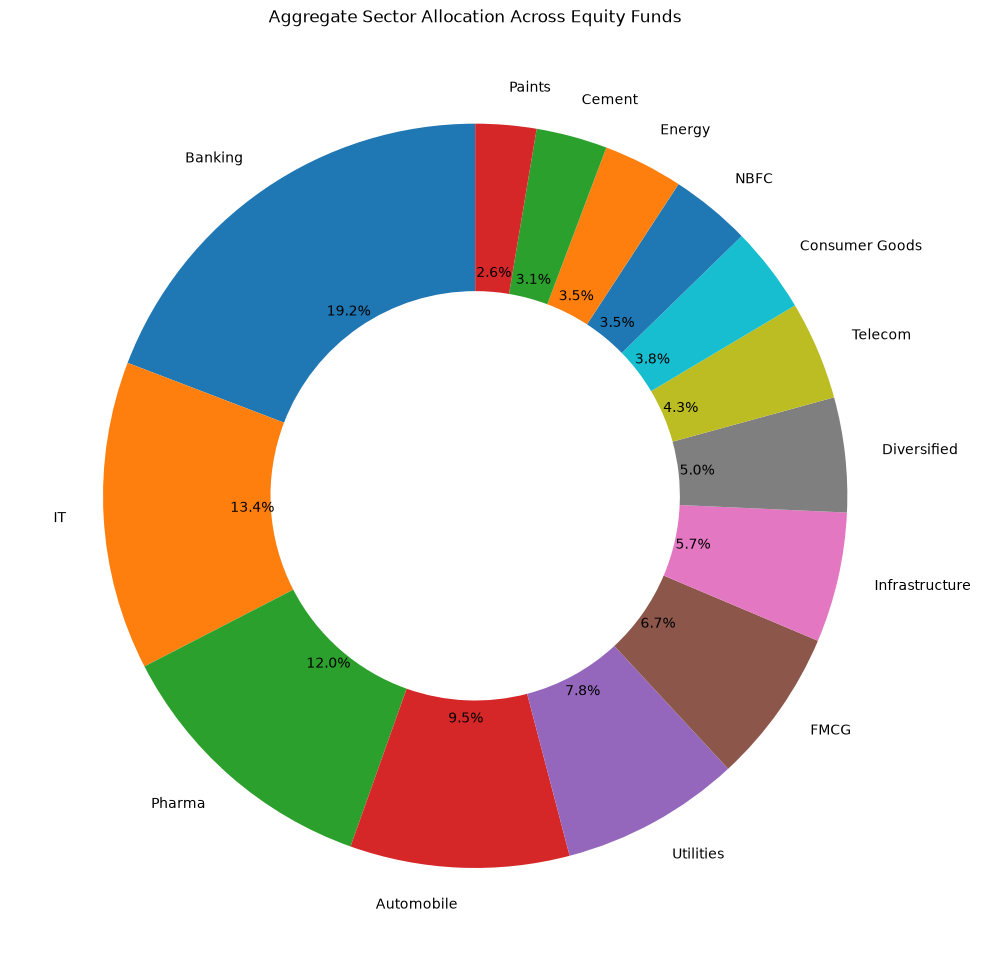

Chart 13 PNG saved successfully!


In [19]:
# Chart 13: Aggregate Sector Allocation - PNG Export

portfolio_file = list(raw_dir.glob("*portfolio_holdings*.csv"))[0]

portfolio_df = pd.read_csv(portfolio_file)

sector_allocation = (
    portfolio_df
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

sector_allocation = sector_allocation[
    sector_allocation["weight_pct"] > 0
].copy()

plt.figure(figsize=(10, 10))

plt.pie(
    sector_allocation["weight_pct"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Aggregate Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_13_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 13 PNG saved successfully!")

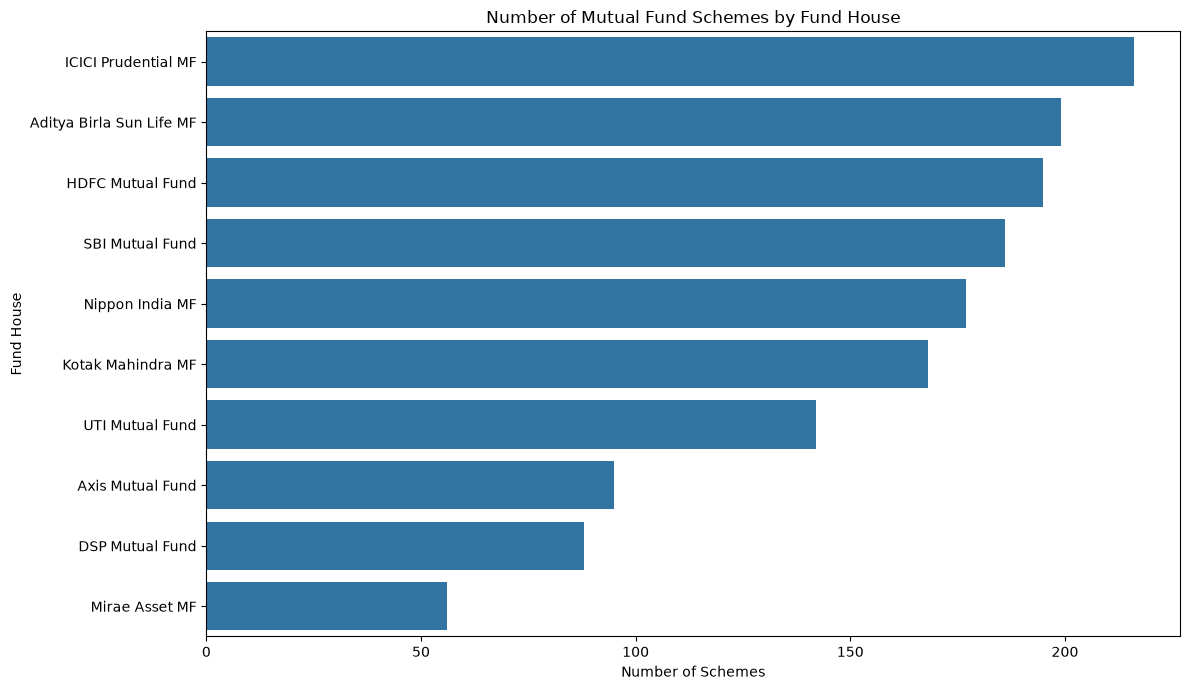

Chart 14 PNG saved successfully!


In [20]:
# Chart 14: Number of Schemes by Fund House - PNG Export

aum_file = list(raw_dir.glob("*aum_by_fund_house*.csv"))[0]

aum_df = pd.read_csv(aum_file)

scheme_count = (
    aum_df
    .groupby("fund_house")["num_schemes"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=scheme_count,
    x="num_schemes",
    y="fund_house"
)

plt.title("Number of Mutual Fund Schemes by Fund House")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_14_fund_house_scheme_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 14 PNG saved successfully!")

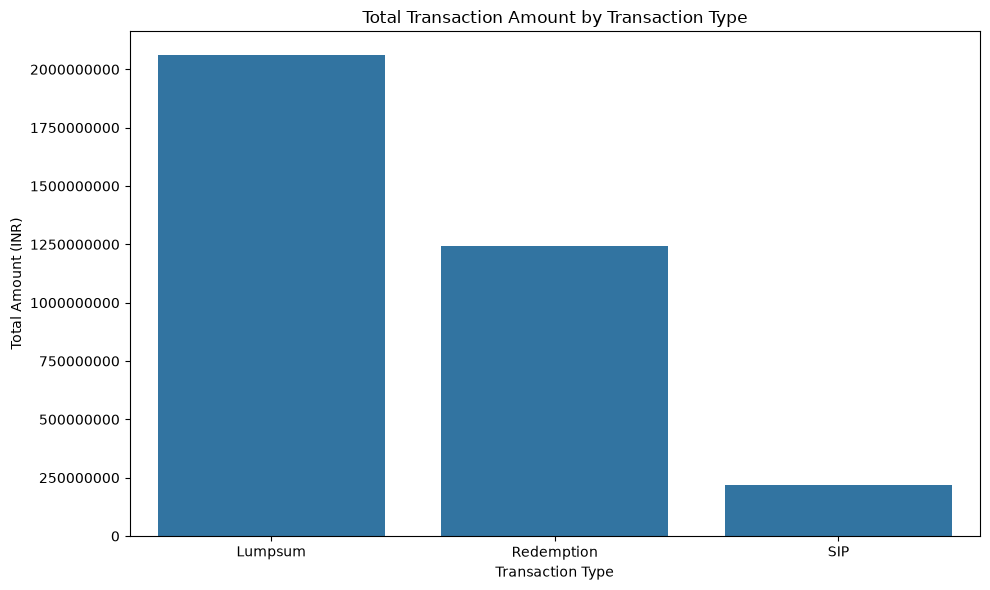

Chart 15 PNG saved successfully!


In [21]:
# Chart 15: Total Transaction Amount by Transaction Type - PNG Export

investor_file = list(raw_dir.glob("*investor_transactions*.csv"))[0]

investor_df = pd.read_csv(investor_file)

transaction_summary = (
    investor_df
    .groupby("transaction_type", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=transaction_summary,
    x="transaction_type",
    y="amount_inr"
)

plt.title("Total Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount (INR)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/chart_15_transaction_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart 15 PNG saved successfully!")

In [22]:
from pathlib import Path

png_dir = Path("../reports/eda_charts")

png_files = sorted(png_dir.glob("*.png"))

print("PNG count:", len(png_files))
print("\nFiles:")

for f in png_files:
    print(f.name)

PNG count: 15

Files:
chart_01_daily_nav_trend.png
chart_02_nav_highlights.png
chart_03_aum_growth.png
chart_04_sip_inflow.png
chart_05_category_inflow_heatmap.png
chart_06_age_group_distribution.png
chart_07_sip_by_age_group.png
chart_08_gender_split.png
chart_09_sip_by_state.png
chart_10_t30_b30_distribution.png
chart_11_folio_growth.png
chart_12_nav_correlation.png
chart_13_sector_allocation.png
chart_14_fund_house_scheme_count.png
chart_15_transaction_type.png
